# Analysis

## Heatmap

In [1]:
from eap.graph import Graph
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def extract_in_graph_attention_counts(graph):
    count_dict = {}

    layers = set()
    heads = set()
    qkv_set = set()

    for edge in graph.edges.values():
        child = edge.child
        if not (child.name.startswith("a") and ".h" in child.name):
            continue
        try:
            layer_str, head_str = child.name[1:].split(".h")
            layer = int(layer_str)
            head = int(head_str)
            qkv = edge.qkv

            layers.add(layer)
            heads.add(head)
            qkv_set.add(qkv)
        except:
            continue

    # count only in-graph edges
    for edge in graph.edges.values():
        if not edge.in_graph.item():
            continue

        child = edge.child
        if not (child.name.startswith("a") and ".h" in child.name):
            continue

        try:
            layer_str, head_str = child.name[1:].split(".h")
            layer = int(layer_str)
            head = int(head_str)
            qkv = edge.qkv

            head_proj = f"h{head}<{qkv}>"
            key = (layer, head_proj)
            count_dict[key] = count_dict.get(key, 0) + 1
        except:
            continue

    # Fill the full matrix with zero if missing
    full_data = []
    for layer in sorted(layers):
        for head in sorted(heads):
            for qkv in sorted(qkv_set):
                head_proj = f"h{head}<{qkv}>"
                count = count_dict.get((layer, head_proj), 0)
                full_data.append((layer, head_proj, count))

    df = pd.DataFrame(full_data, columns=["layer", "head_proj", "count"])
    return df

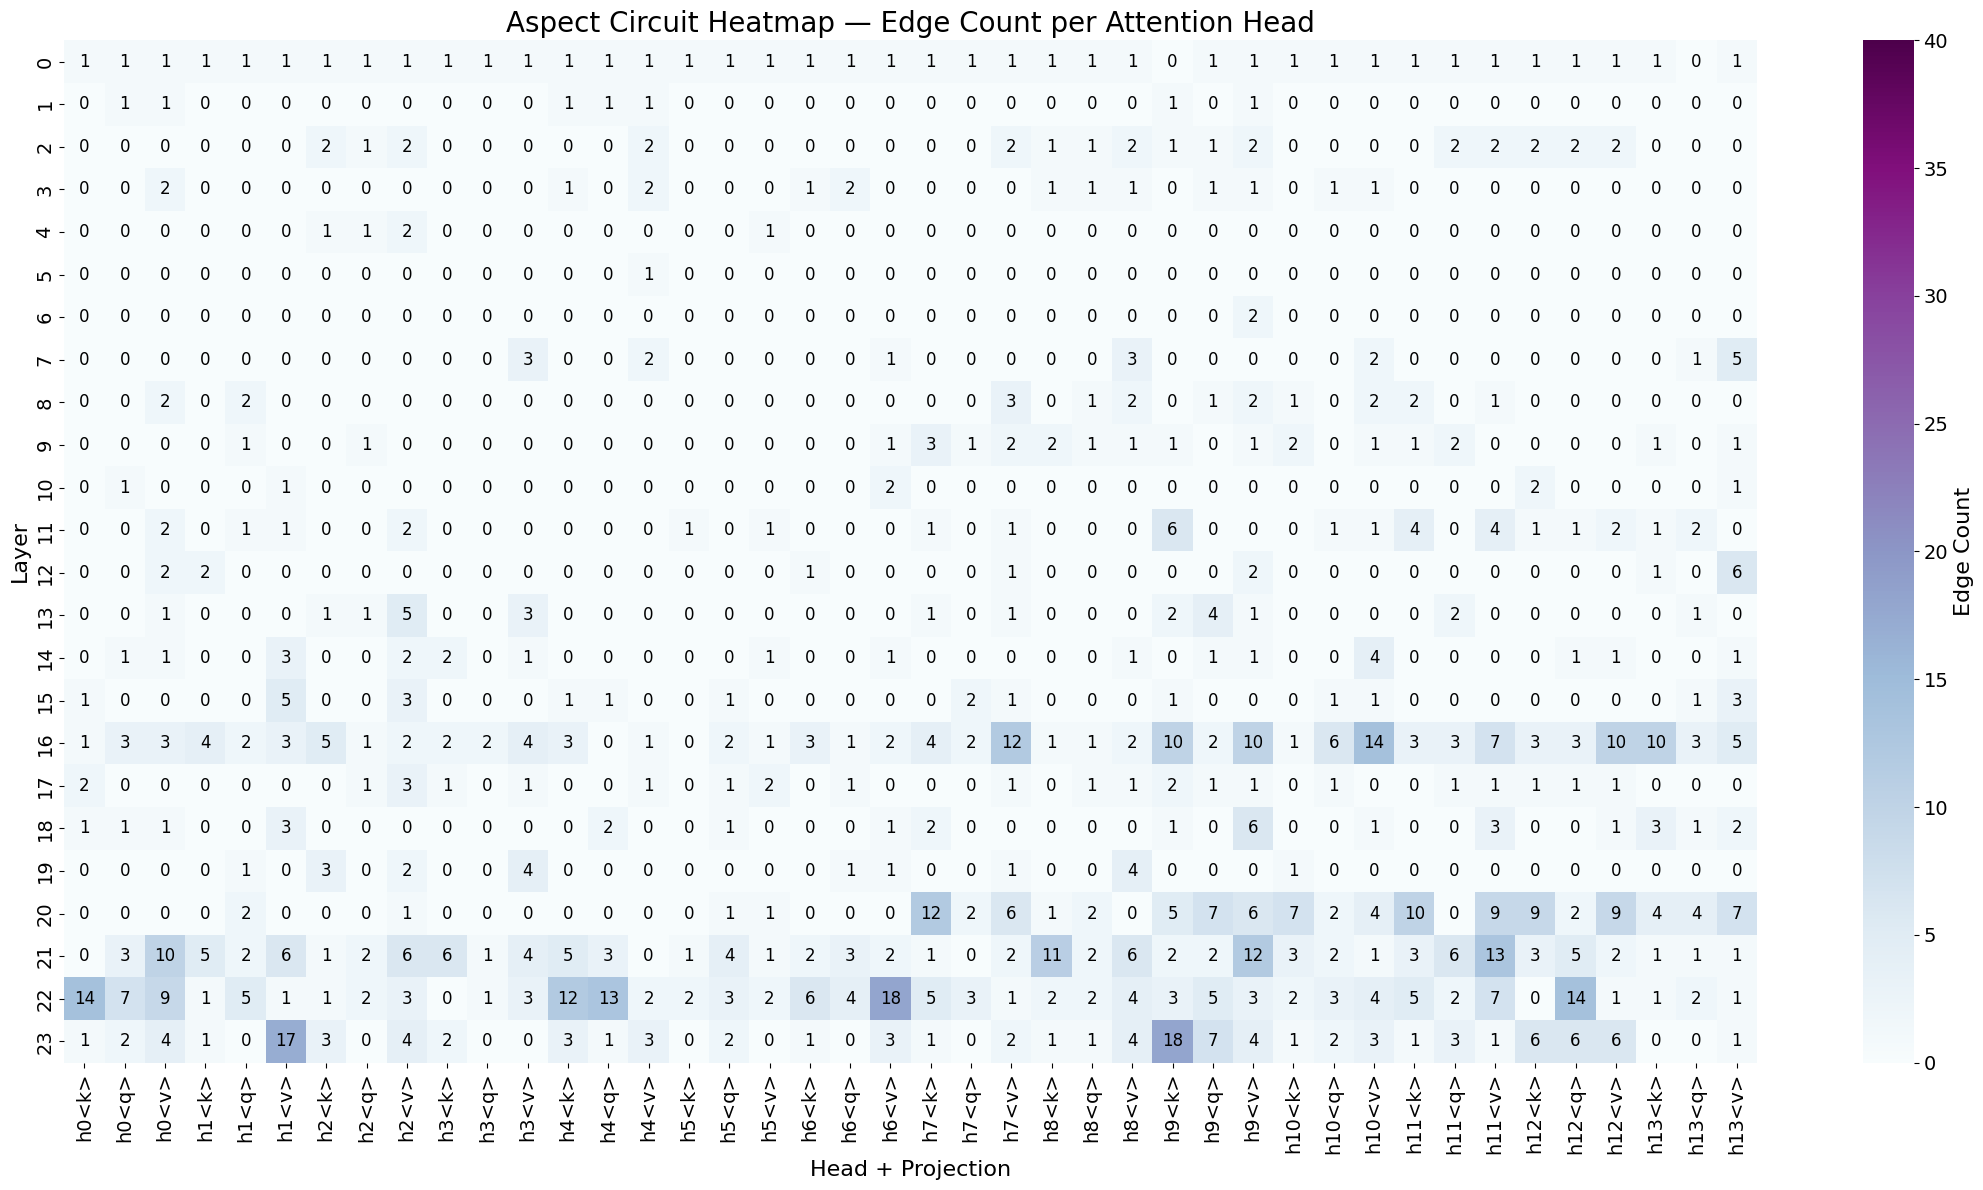

In [2]:
graph = Graph.from_pt("outputs/multitokens/v3/aspect_circuit_topk-2000.pt")
df_count = extract_in_graph_attention_counts(graph)
heatmap_count = df_count.pivot(index="layer", columns="head_proj", values="count").fillna(0)

heatmap_count = heatmap_count.reindex(
    sorted(heatmap_count.columns, key=lambda x: (int(x[1:].split("<")[0]), x[-2])),
    axis=1
)

fig, ax = plt.subplots(figsize=(22, 12))
heatmap = sns.heatmap(
    heatmap_count,
    cmap="BuPu",
    annot=True,
    fmt="d",
    annot_kws={"size": 12, "color": "black", "va": "center"},
    cbar_kws={"label": "Edge Count"},
    ax=ax,
    vmin=0,
    vmax=40
)

ax.set_title("Aspect Circuit Heatmap — Edge Count per Attention Head", fontsize=20)
ax.set_xlabel("Head + Projection", fontsize=16)
ax.set_ylabel("Layer", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=90)
ax.tick_params(axis='y', labelsize=14)


cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14) 
cbar.set_label("Edge Count", fontsize=16)  

plt.tight_layout()
plt.show()


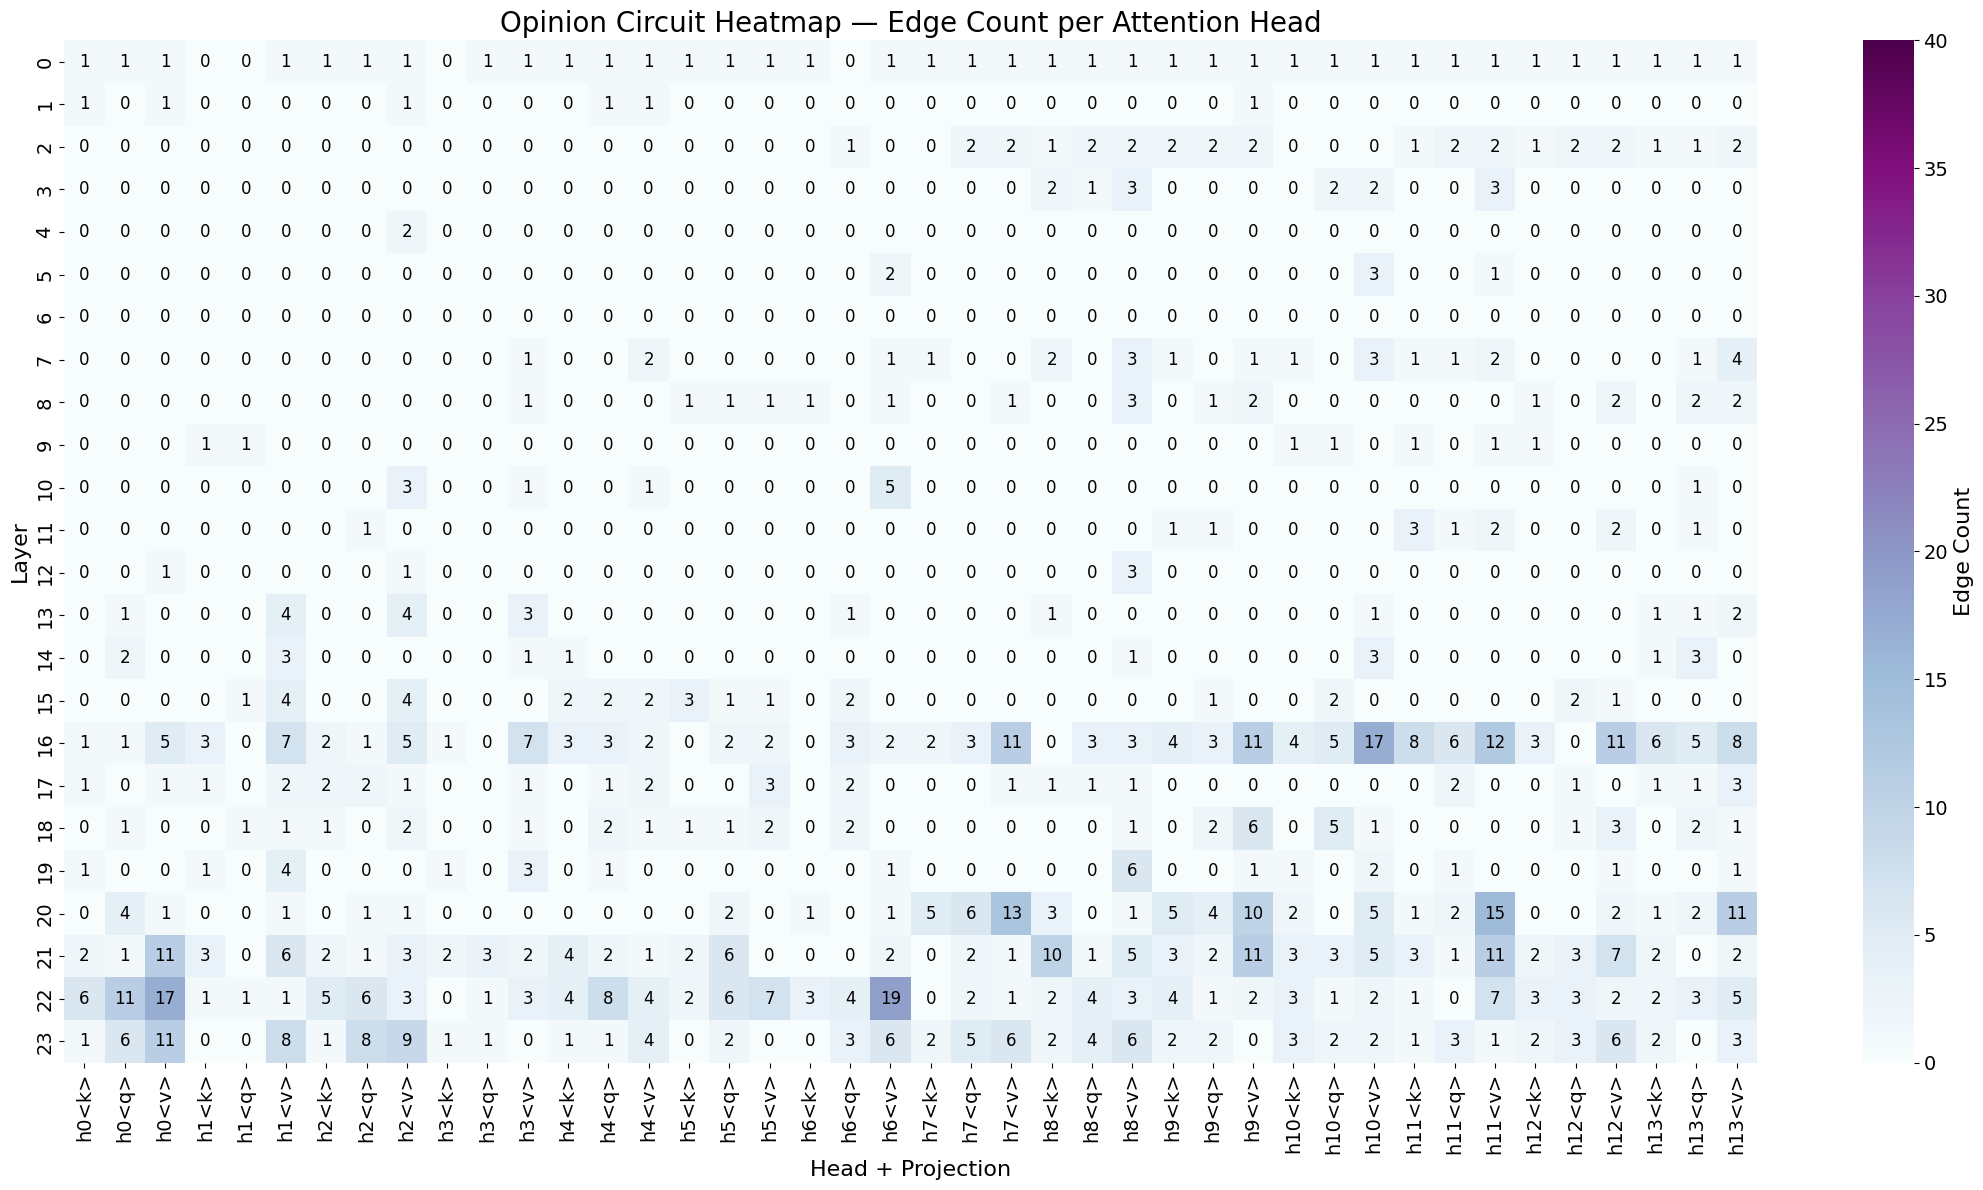

In [3]:
graph = Graph.from_pt("outputs/multitokens/v3/opinion_circuit_topk-2000.pt")
df_count = extract_in_graph_attention_counts(graph)
heatmap_count = df_count.pivot(index="layer", columns="head_proj", values="count").fillna(0)

heatmap_count = heatmap_count.reindex(
    sorted(heatmap_count.columns, key=lambda x: (int(x[1:].split("<")[0]), x[-2])),
    axis=1
)

fig, ax = plt.subplots(figsize=(22, 12))
heatmap = sns.heatmap(
    heatmap_count,
    cmap="BuPu",
    annot=True,
    fmt="d",
    annot_kws={"size": 12, "color": "black", "va": "center"},
    cbar_kws={"label": "Edge Count"},
    ax=ax,
    vmin=0,
    vmax=40
)

ax.set_title("Opinion Circuit Heatmap — Edge Count per Attention Head", fontsize=20)
ax.set_xlabel("Head + Projection", fontsize=16)
ax.set_ylabel("Layer", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=90)
ax.tick_params(axis='y', labelsize=14)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  
cbar.set_label("Edge Count", fontsize=16)  

plt.tight_layout()
plt.show()


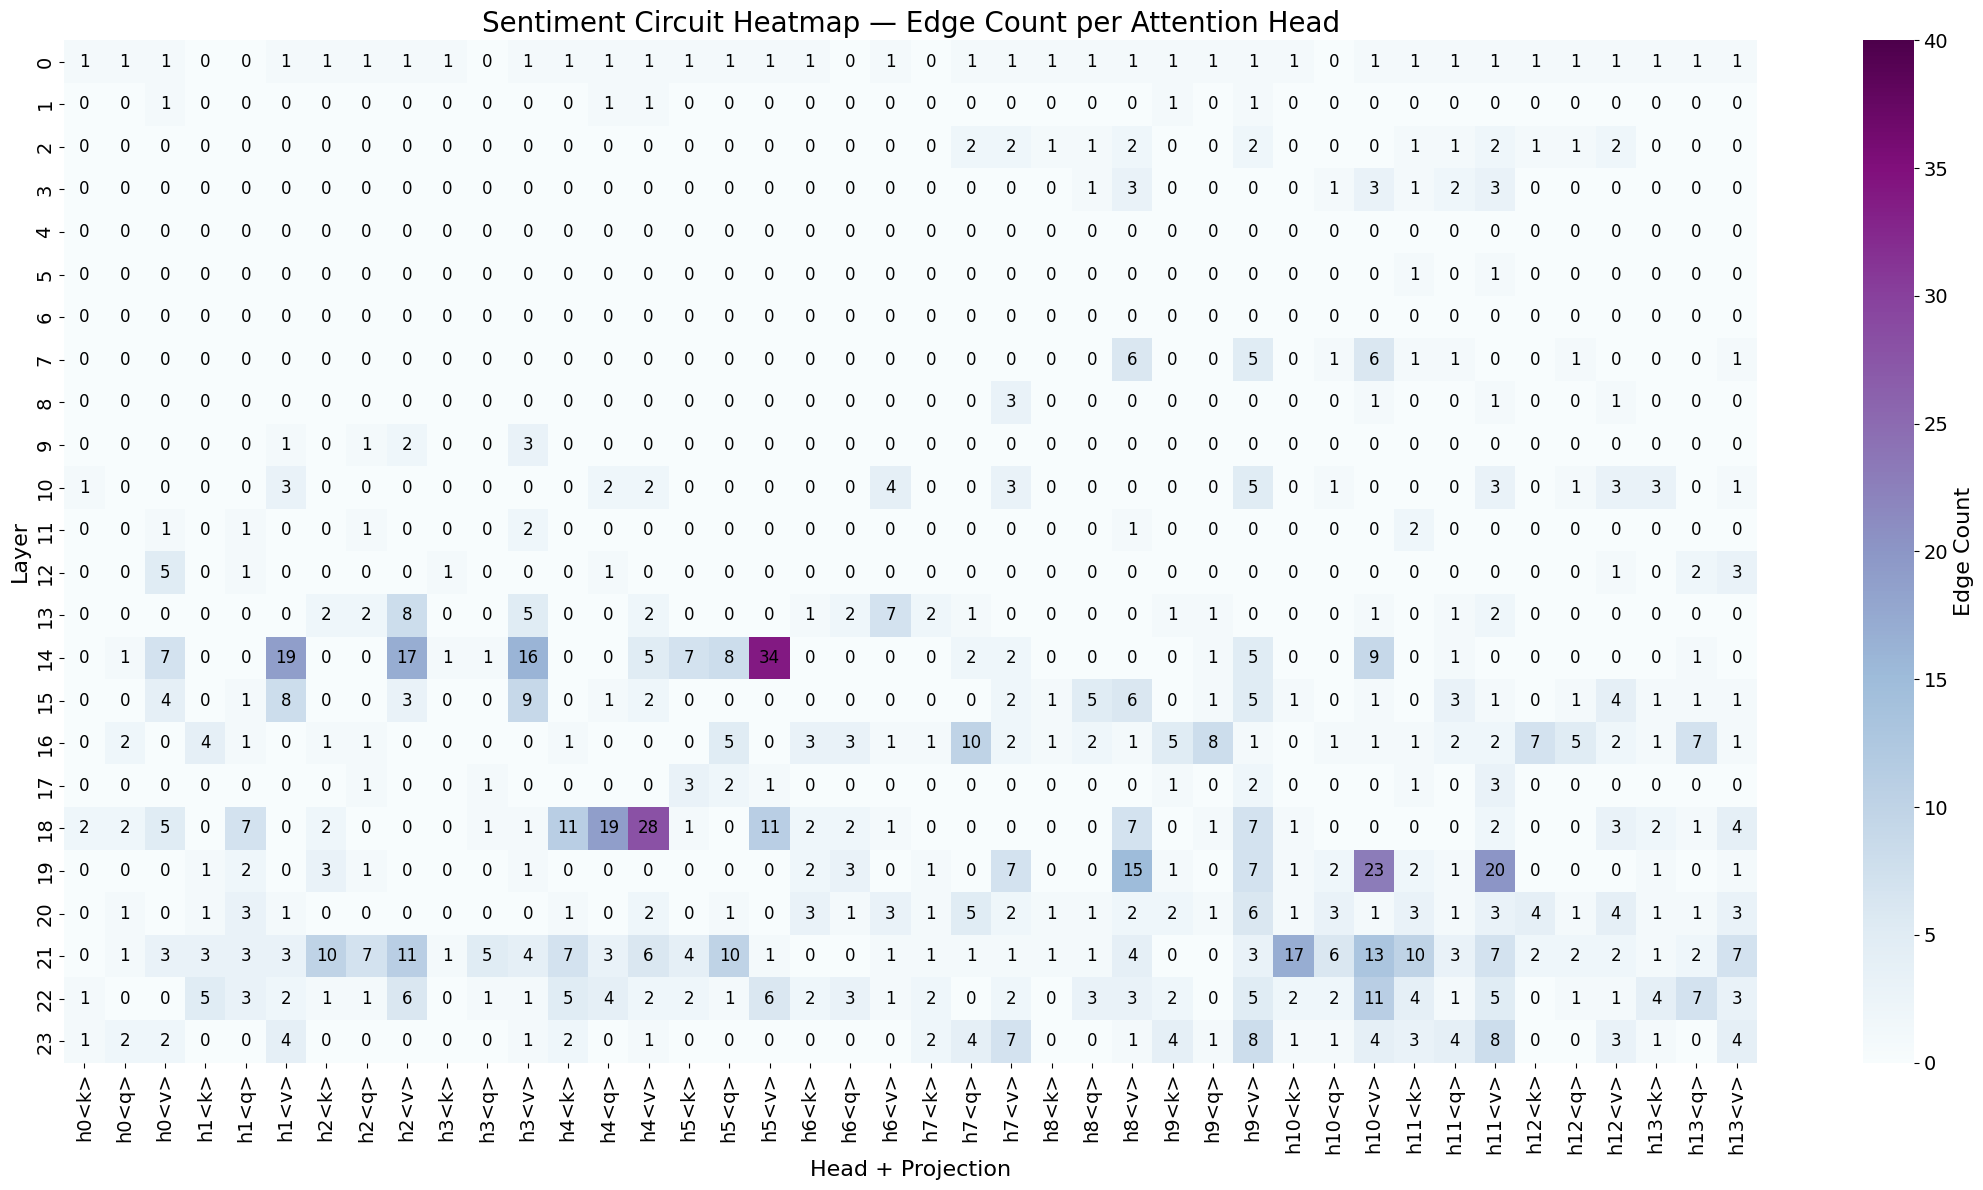

In [4]:
graph = Graph.from_pt("outputs/multitokens/v3/sentiment_circuit_topk-2000.pt")
df_count = extract_in_graph_attention_counts(graph)
heatmap_count = df_count.pivot(index="layer", columns="head_proj", values="count").fillna(0)

heatmap_count = heatmap_count.reindex(
    sorted(heatmap_count.columns, key=lambda x: (int(x[1:].split("<")[0]), x[-2])),
    axis=1
)

fig, ax = plt.subplots(figsize=(22, 12))
heatmap = sns.heatmap(
    heatmap_count,
    cmap="BuPu",
    annot=True,
    fmt="d",
    annot_kws={"size": 12, "color": "black", "va": "center"},
    cbar_kws={"label": "Edge Count"},
    ax=ax,
    vmin=0,
    vmax=40
)

ax.set_title("Sentiment Circuit Heatmap — Edge Count per Attention Head", fontsize=20)
ax.set_xlabel("Head + Projection", fontsize=16)
ax.set_ylabel("Layer", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=90)
ax.tick_params(axis='y', labelsize=14)

# Colorbar font size customization
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  
cbar.set_label("Edge Count", fontsize=16) 

plt.tight_layout()
plt.show()

#### Simultaneously Discovery with AOS

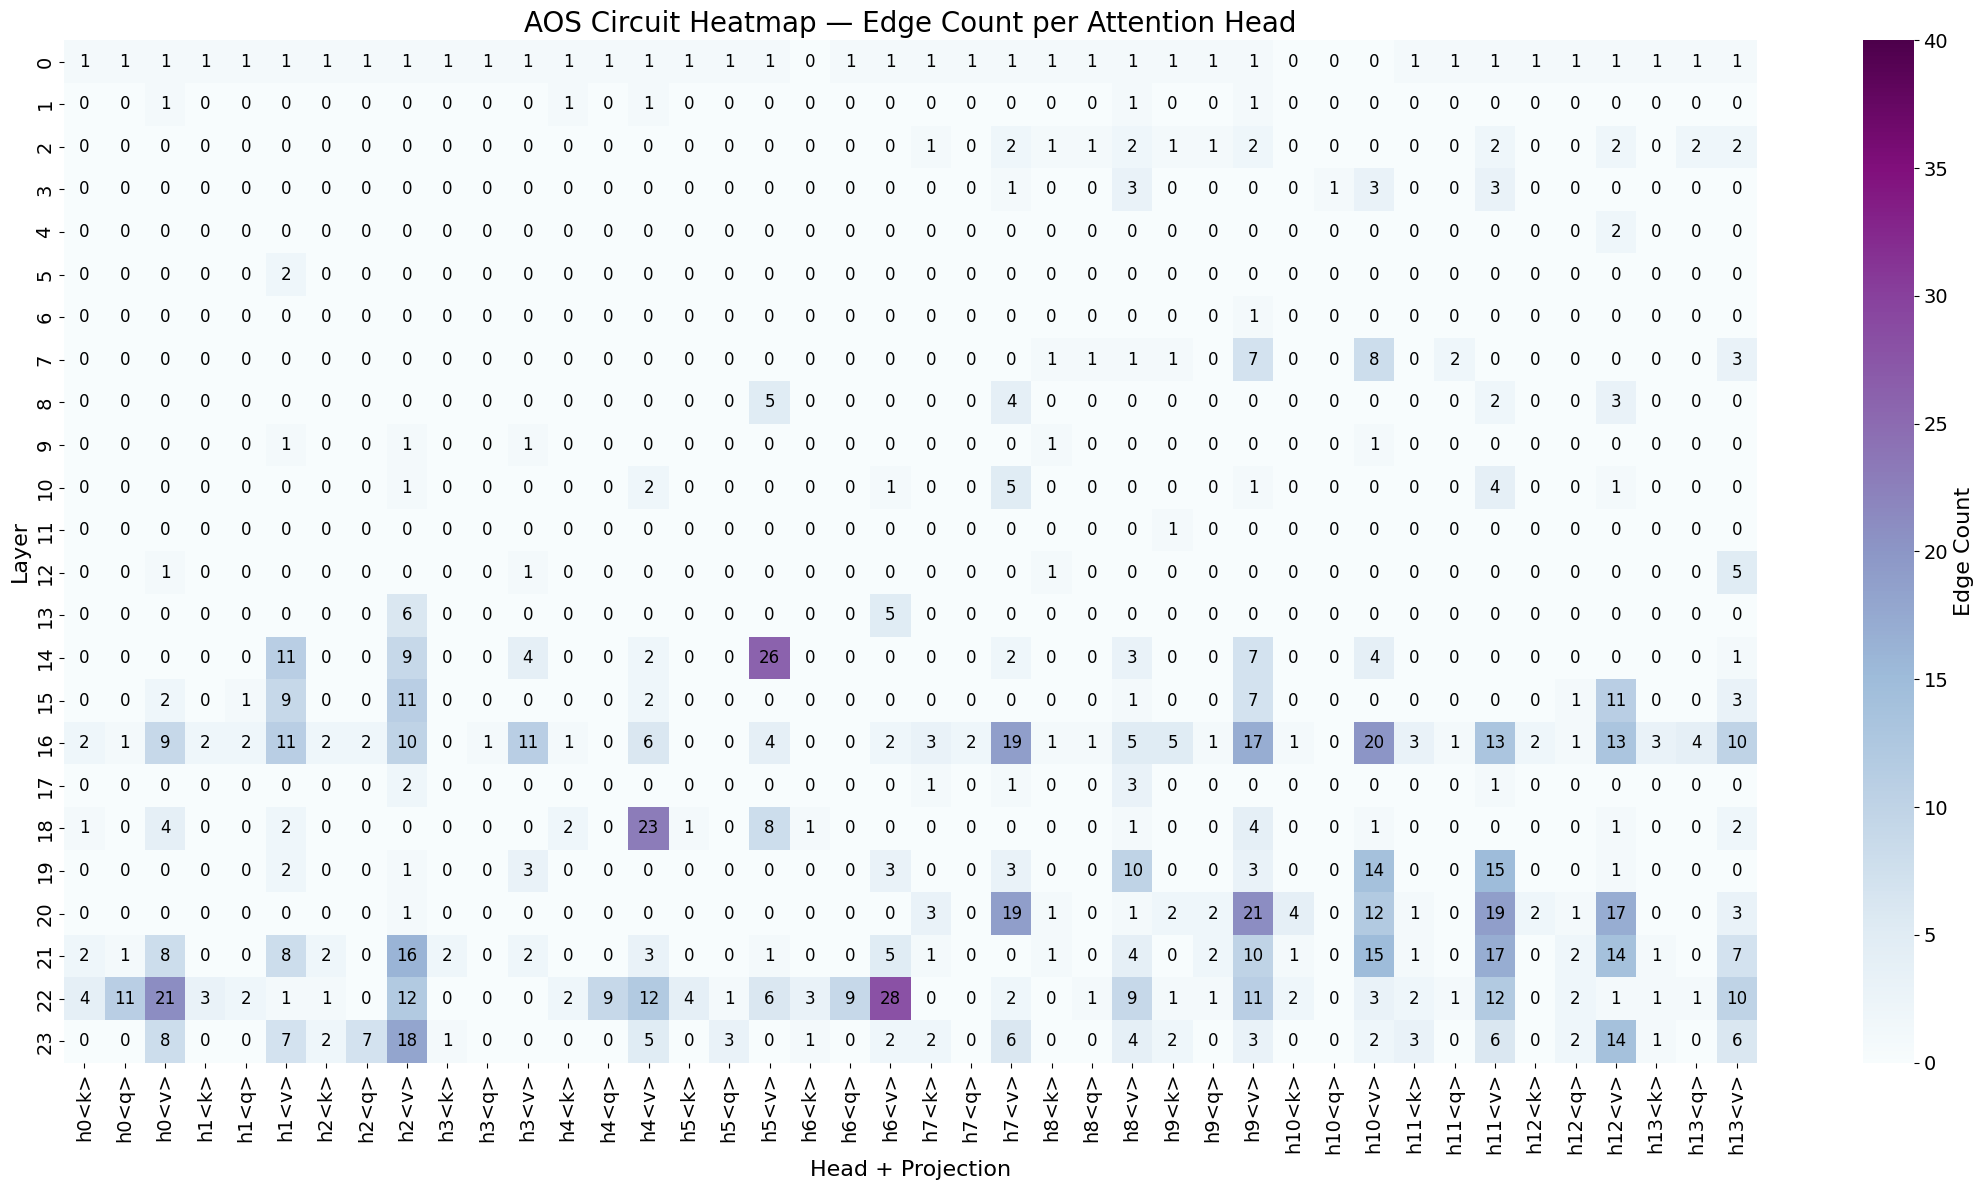

In [8]:
graph = Graph.from_pt("outputs/test_fullAOS_circuit_topk-2000.pt")
df_count = extract_in_graph_attention_counts(graph)
heatmap_count = df_count.pivot(index="layer", columns="head_proj", values="count").fillna(0)

heatmap_count = heatmap_count.reindex(
    sorted(heatmap_count.columns, key=lambda x: (int(x[1:].split("<")[0]), x[-2])),
    axis=1
)

fig, ax = plt.subplots(figsize=(22, 12))
heatmap = sns.heatmap(
    heatmap_count,
    cmap="BuPu",
    annot=True,
    fmt="d",
    annot_kws={"size": 12, "color": "black", "va": "center"},
    cbar_kws={"label": "Edge Count"},
    ax=ax,
    vmin=0,
    vmax=40

)

ax.set_title("AOS Circuit Heatmap — Edge Count per Attention Head", fontsize=20)
ax.set_xlabel("Head + Projection", fontsize=16)
ax.set_ylabel("Layer", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=90)
ax.tick_params(axis='y', labelsize=14)


cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Edge Count", fontsize=16)  

plt.tight_layout()
plt.show()

In [10]:
print(graph.count_included_edges())
print(graph.count_included_nodes())

1898
188


### Union of A, O, and S

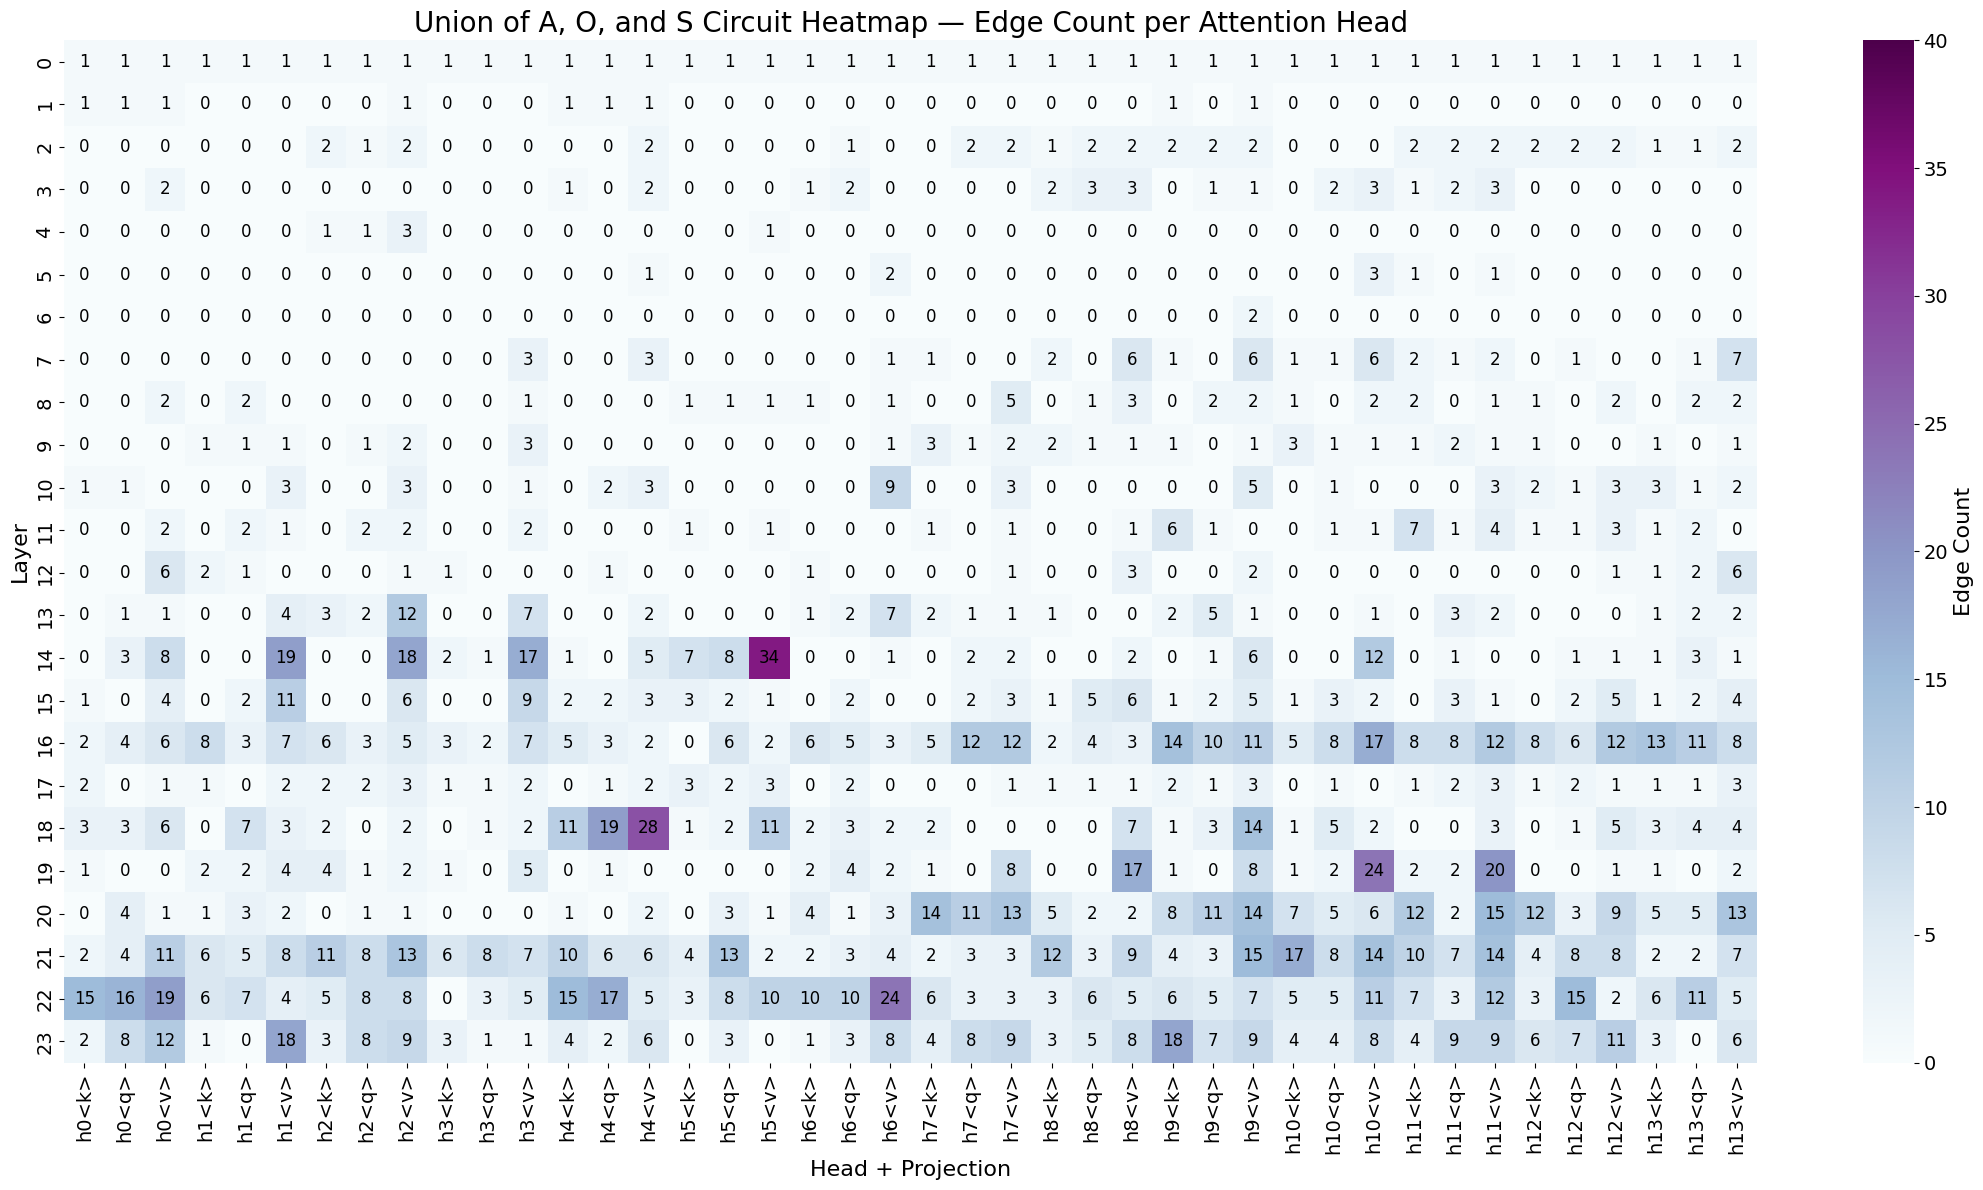

In [7]:
def extract_merged_edge_counts(graphs):
    edge_seen = set()
    count_dict = {}
    layers, heads, qkv_set = set(), set(), set()

    for graph in graphs:
        for edge in graph.edges.values():
            if not edge.in_graph.item():
                continue

            edge_id = (edge.parent.name, edge.child.name, edge.qkv)
            if edge_id in edge_seen:
                continue
            edge_seen.add(edge_id)

            # Only count attention heads (e.g. aX.hY)
            child_name = edge.child.name
            if not (child_name.startswith("a") and ".h" in child_name):
                continue

            try:
                layer_str, head_str = child_name[1:].split(".h")
                layer = int(layer_str)
                head = int(head_str)
                qkv = edge.qkv

                key = (layer, head, qkv)
                count_dict[key] = count_dict.get(key, 0) + 1

                layers.add(layer)
                heads.add(head)
                qkv_set.add(qkv)
            except:
                continue

    # Build full table with 0s
    full_data = []
    for layer in sorted(layers):
        for head in sorted(heads):
            for qkv in sorted(qkv_set):
                head_proj = f"h{head}<{qkv}>"
                count = count_dict.get((layer, head, qkv), 0)
                full_data.append((layer, head_proj, count))

    df = pd.DataFrame(full_data, columns=["layer", "head_proj", "count"])
    return df


aspect_graph = Graph.from_pt("outputs/multitokens/v3/aspect_circuit_topk-2000.pt")
opinion_graph = Graph.from_pt("outputs/multitokens/v3/opinion_circuit_topk-2000.pt")
sentiment_graph = Graph.from_pt("outputs/multitokens/v3/sentiment_circuit_topk-2000.pt")

df_merged = extract_merged_edge_counts([aspect_graph, opinion_graph, sentiment_graph])
heatmap_df = df_merged.pivot(index="layer", columns="head_proj", values="count").fillna(0)
heatmap_df = heatmap_df.reindex(
    sorted(heatmap_df.columns, key=lambda x: (int(x[1:].split("<")[0]), x[-2])),
    axis=1
)

fig, ax = plt.subplots(figsize=(22, 12))
heatmap = sns.heatmap(
    heatmap_df,
    cmap="BuPu",
    annot=True,
    fmt="d",
    annot_kws={"size": 12, "color": "black", "va": "center"},
    cbar_kws={"label": "Edge Count"},
    ax=ax,
    vmin=0,
    vmax=40

)

ax.set_title("Union of A, O, and S Circuit Heatmap — Edge Count per Attention Head", fontsize=20)
ax.set_xlabel("Head + Projection", fontsize=16)
ax.set_ylabel("Layer", fontsize=16)
ax.tick_params(axis='x', labelsize=14, rotation=90)
ax.tick_params(axis='y', labelsize=14)

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=14) 
cbar.set_label("Edge Count", fontsize=16) 

plt.tight_layout()
plt.show()

### Edge Intersections

In [11]:
from eap.graph import Graph

def extract_edge_set(graph):
    """Return set of (parent_name, child_name, qkv) for in-graph edges."""
    return {
        (edge.parent.name, edge.child.name, edge.qkv)
        for edge in graph.edges.values()
        if edge.in_graph.item()
    }

graph_paths = {
    "aspect": "outputs/multitokens/v3/aspect_circuit_topk-2000.pt",
    "opinion": "outputs/multitokens/v3/opinion_circuit_topk-2000.pt",
    "sentiment": "outputs/multitokens/v3/sentiment_circuit_topk-2000.pt",
}


graph_edge_sets = {
    name: extract_edge_set(Graph.from_pt(path))
    for name, path in graph_paths.items()
}

def compare_two_edges(name1, name2):
    set1 = graph_edge_sets[name1]
    set2 = graph_edge_sets[name2]
    only1 = set1 - set2
    only2 = set2 - set1
    both = set1 & set2
    union = set1 | set2

    print(f"\n--- Comparing EDGES: {name1} vs {name2} ---")
    print(f"Total union size: {len(union)}")
    print(f"Total in {name1}: {len(set1)}")
    print(f"Total in {name2}: {len(set2)}\n")

    print(f"ONLY in {name1}: {len(only1)} ({100 * len(only1) / len(union):.1f}%)")
    print(f"ONLY in {name2}: {len(only2)} ({100 * len(only2) / len(union):.1f}%)")
    print(f"IN BOTH: {len(both)} ({100 * len(both) / len(union):.1f}%)")

def compare_three_edges(name1, name2, name3):
    set1 = graph_edge_sets[name1]
    set2 = graph_edge_sets[name2]
    set3 = graph_edge_sets[name3]

    all_union = set1 | set2 | set3
    in_all = set1 & set2 & set3
    only1 = set1 - set2 - set3
    only2 = set2 - set1 - set3
    only3 = set3 - set1 - set2

    print(f"\n--- Comparing EDGES: {name1} + {name2} + {name3} ---")
    print(f"Total union size: {len(all_union)}")
    print(f"Total in {name1}: {len(set1)}")
    print(f"Total in {name2}: {len(set2)}")
    print(f"Total in {name3}: {len(set3)}\n")

    print(f"ONLY in {name1}: {len(only1)} ({100 * len(only1) / len(all_union):.1f}%)")
    print(f"ONLY in {name2}: {len(only2)} ({100 * len(only2) / len(all_union):.1f}%)")
    print(f"ONLY in {name3}: {len(only3)} ({100 * len(only3) / len(all_union):.1f}%)")
    print(f"IN ALL THREE: {len(in_all)} ({100 * len(in_all) / len(all_union):.1f}%)")

compare_two_edges("aspect", "opinion")
compare_two_edges("aspect", "sentiment")
compare_two_edges("opinion", "sentiment")
compare_three_edges("aspect", "opinion", "sentiment")



--- Comparing EDGES: aspect vs opinion ---
Total union size: 2723
Total in aspect: 1854
Total in opinion: 1845

ONLY in aspect: 878 (32.2%)
ONLY in opinion: 869 (31.9%)
IN BOTH: 976 (35.8%)

--- Comparing EDGES: aspect vs sentiment ---
Total union size: 2974
Total in aspect: 1854
Total in sentiment: 1810

ONLY in aspect: 1164 (39.1%)
ONLY in sentiment: 1120 (37.7%)
IN BOTH: 690 (23.2%)

--- Comparing EDGES: opinion vs sentiment ---
Total union size: 2950
Total in opinion: 1845
Total in sentiment: 1810

ONLY in opinion: 1140 (38.6%)
ONLY in sentiment: 1105 (37.5%)
IN BOTH: 705 (23.9%)

--- Comparing EDGES: aspect + opinion + sentiment ---
Total union size: 3642
Total in aspect: 1854
Total in opinion: 1845
Total in sentiment: 1810

ONLY in aspect: 692 (19.0%)
ONLY in opinion: 668 (18.3%)
ONLY in sentiment: 919 (25.2%)
IN ALL THREE: 504 (13.8%)


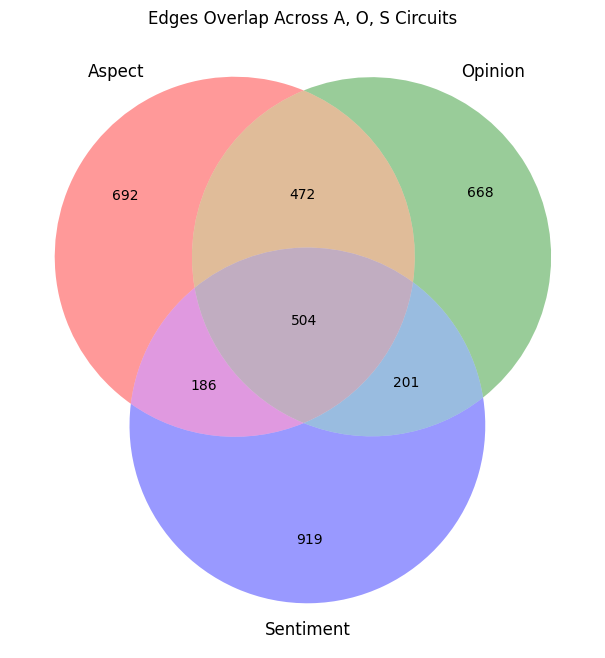

In [25]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

aspect = 1854
opinion = 1845
sentiment = 1810
total_edges = aspect + opinion + sentiment
only_aspect = 692
only_opinion = 668
only_sentiment = 919
in_all = 504

in_aspect_opinion = 976  
in_aspect_sentiment = 690
in_opinion_sentiment = 705

aspect_opinion = in_aspect_opinion - in_all
aspect_sentiment = in_aspect_sentiment - in_all
opinion_sentiment = in_opinion_sentiment - in_all

venn_counts = {
    '100': only_aspect,
    '010': only_opinion,
    '001': only_sentiment,
    '110': aspect_opinion,
    '101': aspect_sentiment,
    '011': opinion_sentiment,
    '111': in_all,
}

# Plot the Venn diagram
plt.figure(figsize=(8, 8))
venn = venn3(subsets=venn_counts, set_labels=('Aspect', 'Opinion', 'Sentiment'))
plt.title("Edges Overlap Across A, O, S Circuits")
plt.show()


### Nodes Instersection

In [13]:
from eap.graph import Graph

def extract_child_qkv_set(graph):
    """Return set of (child_name, qkv) for in-graph attention heads only."""
    return {
        (edge.child.name, edge.qkv)
        for edge in graph.edges.values()
        if edge.in_graph.item()
        and edge.child.name.startswith("a")
        and ".h" in edge.child.name
    }

graph_paths = {
    "aspect": "outputs/multitokens/v3/aspect_circuit_topk-2000.pt",
    "opinion": "outputs/multitokens/v3/opinion_circuit_topk-2000.pt",
    "sentiment": "outputs/multitokens/v3/sentiment_circuit_topk-2000.pt",
}

graph_node_sets = {
    name: extract_child_qkv_set(Graph.from_pt(path))
    for name, path in graph_paths.items()
}

def compare_two(name1, name2):
    set1 = graph_node_sets[name1]
    set2 = graph_node_sets[name2]
    only1 = set1 - set2
    only2 = set2 - set1
    both = set1 & set2
    union = set1 | set2

    print(f"\n--- Comparing CHILD+QKV nodes: {name1} vs {name2} ---")
    print(f"Total union size: {len(union)}")
    print(f"Total in {name1}: {len(set1)}")
    print(f"Total in {name2}: {len(set2)}\n")

    print(f"ONLY in {name1}: {len(only1)} ({100 * len(only1) / len(union):.1f}%)")
    print(f"ONLY in {name2}: {len(only2)} ({100 * len(only2) / len(union):.1f}%)")
    print(f"IN BOTH: {len(both)} ({100 * len(both) / len(union):.1f}%)")

def compare_three(name1, name2, name3):
    set1 = graph_node_sets[name1]
    set2 = graph_node_sets[name2]
    set3 = graph_node_sets[name3]

    all_union = set1 | set2 | set3
    in_all = set1 & set2 & set3
    only1 = set1 - set2 - set3
    only2 = set2 - set1 - set3
    only3 = set3 - set1 - set2

    print(f"\n--- Comparing CHILD+QKV nodes: {name1} + {name2} + {name3} ---")
    print(f"Total union size: {len(all_union)}")
    print(f"Total in {name1}: {len(set1)}")
    print(f"Total in {name2}: {len(set2)}")
    print(f"Total in {name3}: {len(set3)}\n")

    print(f"ONLY in {name1}: {len(only1)} ({100 * len(only1) / len(all_union):.1f}%)")
    print(f"ONLY in {name2}: {len(only2)} ({100 * len(only2) / len(all_union):.1f}%)")
    print(f"ONLY in {name3}: {len(only3)} ({100 * len(only3) / len(all_union):.1f}%)")
    print(f"IN ALL THREE: {len(in_all)} ({100 * len(in_all) / len(all_union):.1f}%)")

compare_two("aspect", "opinion")
compare_two("aspect", "sentiment")
compare_two("opinion", "sentiment")
compare_three("aspect", "opinion", "sentiment")



--- Comparing CHILD+QKV nodes: aspect vs opinion ---
Total union size: 518
Total in aspect: 406
Total in opinion: 382

ONLY in aspect: 136 (26.3%)
ONLY in opinion: 112 (21.6%)
IN BOTH: 270 (52.1%)

--- Comparing CHILD+QKV nodes: aspect vs sentiment ---
Total union size: 516
Total in aspect: 406
Total in sentiment: 368

ONLY in aspect: 148 (28.7%)
ONLY in sentiment: 110 (21.3%)
IN BOTH: 258 (50.0%)

--- Comparing CHILD+QKV nodes: opinion vs sentiment ---
Total union size: 503
Total in opinion: 382
Total in sentiment: 368

ONLY in opinion: 135 (26.8%)
ONLY in sentiment: 121 (24.1%)
IN BOTH: 247 (49.1%)

--- Comparing CHILD+QKV nodes: aspect + opinion + sentiment ---
Total union size: 584
Total in aspect: 406
Total in opinion: 382
Total in sentiment: 368

ONLY in aspect: 81 (13.9%)
ONLY in opinion: 68 (11.6%)
ONLY in sentiment: 66 (11.3%)
IN ALL THREE: 203 (34.8%)


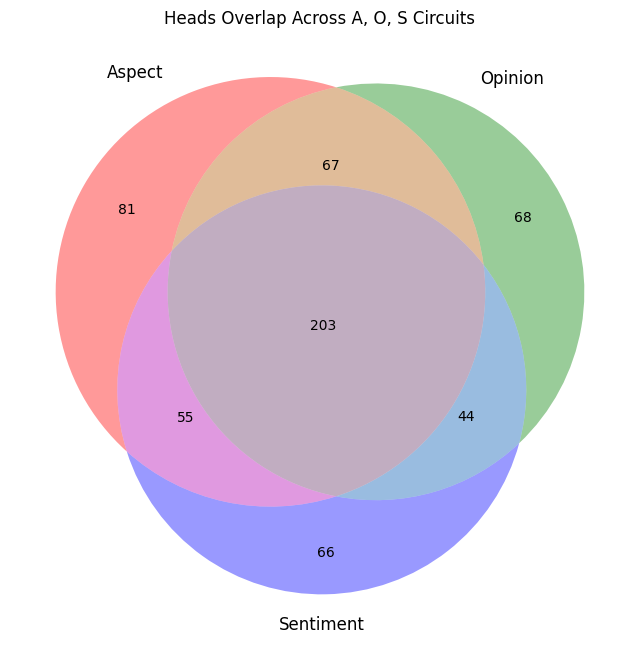

In [22]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

aspect = 406
opinion = 382
sentiment = 368
only_aspect = 81
only_opinion = 68
only_sentiment = 66
in_all = 203

in_aspect_opinion = 270  
in_aspect_sentiment = 258
in_opinion_sentiment = 247

aspect_opinion = in_aspect_opinion - in_all
aspect_sentiment = in_aspect_sentiment - in_all
opinion_sentiment = in_opinion_sentiment - in_all

venn_counts = {
    '100': only_aspect,
    '010': only_opinion,
    '001': only_sentiment,
    '110': aspect_opinion,
    '101': aspect_sentiment,
    '011': opinion_sentiment,
    '111': in_all,
}

plt.figure(figsize=(8, 8))
venn = venn3(subsets=venn_counts, set_labels=('Aspect', 'Opinion', 'Sentiment'))
plt.title("Heads Overlap Across A, O, S Circuits")
plt.show()


### Evaluation Results

In [28]:
import os
import json
import pandas as pd

# root_dir = "outputs/evals/eap/test-sunda_circuit-indo_finetune-sunda/diff_sample_size" 
root_dir = "outputs/evals/eap/indo-indo/diff_sample_size" 
# root_dir = "outputs/evals/eap/indo-indo/test_full_AOS" 
# root_dir = "outputs/evals/eap/indo-indo/small_sample_size"

rows = []

for folder_name in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder_name)
    json_path = os.path.join(folder_path, "evaluation_results.json")

    if os.path.isdir(folder_path) and os.path.exists(json_path):
        with open(json_path) as f:
            data = json.load(f)

        precision_avg = sum(v for k, v in data.items() if k.startswith("precision_")) / 5
        recall_avg = sum(v for k, v in data.items() if k.startswith("recall_")) / 5
        f1_avg = sum(v for k, v in data.items() if k.startswith("f1_")) / 5

        if "topk" in folder_name:
            group = folder_name.split("epochs-20")[-1][1:]
        else:
            groups = folder_name.split("epochs-20")
            if groups != '':
                group = "full" + groups[-1]
            else:
                group = "full"

        rows.append({
            "group": group,
            "avg_precision": precision_avg,
            "avg_recall": recall_avg,
            "avg_f1": f1_avg
        })

df = pd.DataFrame(rows)

df["n"] = df["group"].str.extract(r"n(\d+)").squeeze().fillna(15000).astype(int)

    
df = df.sort_values(by="n")

print(df)

               group  avg_precision  avg_recall     avg_f1      n
0    topk-1000_n5000      68.883964   60.839110  64.610336   5000
1    topk-2000_n5000      70.704760   61.605254  65.829035   5000
4         full_n5000      68.303259   61.152864  64.527489   5000
14   topk-5000_n5000      67.679013   56.716527  61.695754   5000
6    topk-1000_n7500      66.823411   59.562204  62.983070   7500
15   topk-2000_n7500      58.812350   59.985407  59.382178   7500
13   topk-5000_n7500      66.036387   57.417001  61.423615   7500
5         full_n7500      65.959408   58.737687  62.130439   7500
7        full_n10000      65.699085   59.036848  62.178207  10000
3   topk-2000_n10000      69.003580   58.781467  63.482442  10000
2   topk-1000_n10000      64.986278   57.621306  61.078924  10000
8   topk-5000_n10000      67.524859   57.292959  61.986196  10000
11              full      67.236326   57.219993  61.819374  15000
10         topk-1000      64.169511   62.736228  63.405663  15000
9         

/tmp/ipykernel_3520255/853420525.py:17: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.lineplot(


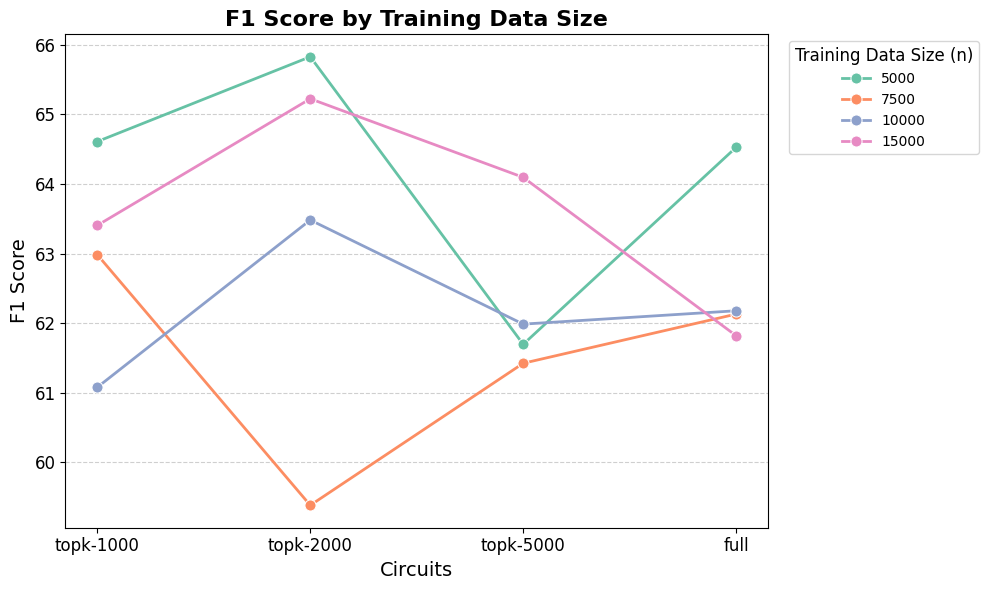

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

df["method"] = df["group"].str.extract(r"(topk-\d+|full)")

df["method_order"] = df["method"].apply(
    lambda x: int(x.split("-")[1]) if x.startswith("topk") else 99999
)

df = df.sort_values(by="method_order")
ordered_methods = df["method"].unique().tolist()
df["method"] = pd.Categorical(df["method"], categories=ordered_methods, ordered=True)

plt.figure(figsize=(10, 6))
palette = sns.color_palette("Set2")  # or try "colorblind" or "tab10"

sns.lineplot(
    data=df,
    x="method",
    y="avg_f1",
    hue="n",
    marker="o",
    markersize=8,
    linewidth=2,
    palette=palette
)

plt.title("F1 Score by Training Data Size", fontsize=16, fontweight="bold")
plt.xlabel("Circuits", fontsize=14)
plt.ylabel("F1 Score", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.legend(title="Training Data Size (n)", title_fontsize=12, fontsize=10, loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()

# Optional save
# plt.savefig("avg_f1_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

### Inferences

In [33]:
from src import load_finetuned_model_lens_from_dir

model_path = "outputs/models/eap/diff_sample_size/2025-06-09 19:19:03.268665_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-20_n5000"
model = load_finetuned_model_lens_from_dir(model_path)
model.to("cuda")
model.eval()

test_list = [
            "pelayanan ramah , kamar nyaman dan fasilitas lengkap . hanya airnya showernya kurang panas . [A] [O] [S]",
            ]

gr_list = [
           "[A] pelayanan [O] ramah [S] positive [SSEP] [A] kamar [O] nyaman [S] positive [SSEP] [A] fasilitas [O] lengkap [S] positive [SSEP] [A] airnya showernya [O] kurang panas [S] negative",
        ]

for iteration in range(1):
    print("\n======================")
    print("iteration", iteration)
    for i, test in enumerate(test_list):
        output = model.generate(test, 
                       max_new_tokens=128,
                       stop_at_eos=True,
                       return_type="str",
                        )
        print("\nprompt: ", test)
        print("\ntarget: ", gr_list[i])
        print("\nresult: ", output.split("[A] [O] [S]")[1])

Moving model to device:  cuda

iteration 0


  0%|          | 0/128 [00:00<?, ?it/s]


prompt:  pelayanan ramah , kamar nyaman dan fasilitas lengkap . hanya airnya showernya kurang panas . [A] [O] [S]

target:  [A] pelayanan [O] ramah [S] positive [SSEP] [A] kamar [O] nyaman [S] positive [SSEP] [A] fasilitas [O] lengkap [S] positive [SSEP] [A] airnya showernya [O] kurang panas [S] negative

result:   [A] pelayanan [O] ramah [S] positive [SSEP] [A] kamar [O] nyaman [S] positive [SSEP] [A] fasilitas [O] lengkap [S] positive [SSEP] [A] airnya [O] kurang panas [S] negative
